In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pinn import PINN, SIREN, SafeNet, HyResPINN, pde_loss, bc_loss, u_exact


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {device}')

Устройство: cuda


In [3]:
def sample_interior(N):
    pts = torch.rand(N, 2)
    pts.requires_grad_(True)
    return pts


def sample_boundary(N):
    n = N // 4
    # bottom: y=0, x in [0,1]
    bottom = torch.stack([torch.rand(n), torch.zeros(n)], dim=1)
    # top: y=1
    top = torch.stack([torch.rand(n), torch.ones(n)], dim=1)
    # left: x=0
    left = torch.stack([torch.zeros(n), torch.rand(n)], dim=1)
    # right: x=1
    right = torch.stack([torch.ones(n + N % 4), torch.rand(n + N % 4)], dim=1)
    return torch.cat([bottom, top, left, right], dim=0)

In [4]:
save_path_params_pinn = 'models_params/pinn_params.json'
save_path_params_siren = 'models_params/siren_params.json'
save_path_params_safenet = 'models_params/safenet_params.json'
save_path_params_hyres = 'models_params/hyres_params.json'

In [5]:
import json

import optuna
from optuna.pruners import MedianPruner
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS       = 20
N_EPOCHS_TRIAL = 5000
PRUNE_INTERVAL = 400
N_VIS_OPT      = 60

# Дефолты на случай если пропустить эту ячейку
best_pinn    = {}
best_siren   = {}
best_safenet = {}


def _eval_grid():
    x = torch.linspace(0, 1, N_VIS_OPT, device=device)
    y = torch.linspace(0, 1, N_VIS_OPT, device=device)
    XX, YY = torch.meshgrid(x, y, indexing='ij')
    xy = torch.stack([XX.flatten(), YY.flatten()], dim=1)
    u_t = u_exact(xy[:, 0], xy[:, 1]).reshape(N_VIS_OPT, N_VIS_OPT).cpu().numpy()
    return xy, u_t

_xy_vis_opt, _u_true_opt = _eval_grid()


def _rel_l2_opt(model):
    model.eval()
    with torch.no_grad():
        u_p = model(_xy_vis_opt).squeeze().reshape(N_VIS_OPT, N_VIS_OPT).cpu().numpy()
    model.train()
    return float(np.linalg.norm(u_p - _u_true_opt) / np.linalg.norm(_u_true_opt))


def _run_study(build_model_fn, n_trials=N_TRIALS, name='study'):
    def objective(trial):
        model, lam = build_model_fn(trial)
        lr  = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
        opt = torch.optim.Adam(model.parameters(), lr=lr)
        xy_col = torch.rand(2000, 2, device=device, requires_grad=True)
        xy_bc  = sample_boundary(500).to(device)
        for ep in range(1, N_EPOCHS_TRIAL + 1):
            xy_col.grad = None
            opt.zero_grad()
            loss = pde_loss(model, xy_col) + lam * bc_loss(model, xy_bc)
            if not torch.isfinite(loss):
                return 1.0
            loss.backward()
            opt.step()
            if ep % PRUNE_INTERVAL == 0:
                l2 = _rel_l2_opt(model)
                trial.report(l2, ep)
                if trial.should_prune():
                    raise optuna.exceptions.TrialPruned()
        return _rel_l2_opt(model)

    study = optuna.create_study(
        direction='minimize',
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=PRUNE_INTERVAL * 2),
        study_name=name,
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f"{name}: лучшие параметры = {study.best_params}, L2 = {study.best_value:.4e}")
    return study.best_params


# --- PINN ---
print("=== Поиск гиперпараметров PINN ===")
def _build_pinn(trial):
    width  = trial.suggest_categorical('hidden_width',  [32, 64, 128])
    layers = trial.suggest_int('hidden_layers', 2, 6)
    lam    = trial.suggest_float('lambda_bc', 1.0, 100.0, log=True)
    torch.manual_seed(0)
    return PINN(hidden_layers=layers, hidden_width=width).to(device), lam

best_pinn = _run_study(_build_pinn, name='pinn_search')

# --- SIREN ---
print("\n=== Поиск гиперпараметров SIREN ===")
def _build_siren(trial):
    width   = trial.suggest_categorical('hidden_width',  [32, 64, 128])
    layers  = trial.suggest_int('hidden_layers', 2, 6)
    omega_0 = trial.suggest_int('omega_0', 5, 50)
    lam     = trial.suggest_float('lambda_bc', 1.0, 100.0, log=True)
    torch.manual_seed(0)
    return SIREN(hidden_layers=layers, hidden_width=width, omega_0=omega_0).to(device), lam

best_siren = _run_study(_build_siren, name='siren_search')

# --- SafeNet ---
print("\n=== Поиск гиперпараметров SafeNet ===")
def _build_safenet(trial):
    n_fourier = trial.suggest_categorical('n_fourier', [128, 256, 512])
    sigma     = trial.suggest_float('sigma', 1.0, 20.0)
    layers    = trial.suggest_int('hidden_layers', 1, 3)
    width     = trial.suggest_categorical('hidden_width', [32, 64, 128])
    lam       = trial.suggest_float('lambda_bc', 1.0, 100.0, log=True)
    torch.manual_seed(0)
    return SafeNet(n_fourier=n_fourier, sigma=sigma,
                   hidden_layers=layers, hidden_width=width).to(device), lam

best_safenet = _run_study(_build_safenet, name='safenet_search')


# --- HyResPINN ---
print("\n=== Поиск гиперпараметров HyResPINN ===")
best_hyres = {}
def _build_hyres(trial):
    width   = trial.suggest_categorical('hidden_width',  [32, 64, 128])
    layers  = trial.suggest_int('hidden_layers', 2, 4)
    n_rbf   = trial.suggest_categorical('n_rbf', [32, 64, 128])
    lam     = trial.suggest_float('lambda_bc', 1.0, 100.0, log=True)
    torch.manual_seed(0)
    return HyResPINN(hidden_layers=layers, hidden_width=width, n_rbf=n_rbf).to(device), lam

best_hyres = _run_study(_build_hyres, name='hyres_search')

print("\nПоиск завершён")

for params, save_path in [
    (best_pinn, save_path_params_pinn),
    (best_siren, save_path_params_siren),
    (best_safenet, save_path_params_safenet),
    (best_hyres, save_path_params_hyres),
]:
    with open(save_path, 'w') as f:
        json.dump(params, f, indent=4)

/home/calculation-02/numeric-methods-pinns/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== Поиск гиперпараметров PINN ===


Best trial: 19. Best value: 0.0167474: 100%|██████████| 20/20 [07:37<00:00, 22.89s/it]


pinn_search: лучшие параметры = {'hidden_width': 128, 'hidden_layers': 6, 'lambda_bc': 97.98189454789653, 'lr': 0.00022235768427125718}, L2 = 1.6747e-02

=== Поиск гиперпараметров SIREN ===


Best trial: 16. Best value: 0.00306911: 100%|██████████| 20/20 [06:46<00:00, 20.35s/it]


siren_search: лучшие параметры = {'hidden_width': 64, 'hidden_layers': 3, 'omega_0': 25, 'lambda_bc': 92.70158971323106, 'lr': 7.670035337759973e-05}, L2 = 3.0691e-03

=== Поиск гиперпараметров SafeNet ===


Best trial: 14. Best value: 0.0100911: 100%|██████████| 20/20 [08:43<00:00, 26.19s/it]


safenet_search: лучшие параметры = {'n_fourier': 128, 'sigma': 11.747895410708516, 'hidden_layers': 3, 'hidden_width': 64, 'lambda_bc': 30.639354892348646, 'lr': 0.0003350324221271991}, L2 = 1.0091e-02

=== Поиск гиперпараметров HyResPINN ===


Best trial: 15. Best value: 0.00945446: 100%|██████████| 20/20 [10:09<00:00, 30.49s/it]

hyres_search: лучшие параметры = {'hidden_width': 64, 'hidden_layers': 3, 'n_rbf': 32, 'lambda_bc': 98.67520913037332, 'lr': 0.0004607255680130148}, L2 = 9.4545e-03

Поиск завершён


In [6]:
import json

best_hyres   = {}
torch.manual_seed(42)

all_params = {}
for name, save_path in [
    ('pinn', save_path_params_pinn),
    ('siren', save_path_params_siren),
    ('safenet', save_path_params_safenet),
    ('hyres', save_path_params_hyres),
]:
    with open(save_path, 'r') as f:
        all_params[name] = json.load(f)

best_pinn    = all_params['pinn']
best_siren   = all_params['siren']
best_safenet = all_params['safenet']
best_hyres   = all_params['hyres']

# --- PINN ---
_pinn_cfg = {
    'lr':            best_pinn.get('lr',           1e-3),
    'hidden_width':  best_pinn.get('hidden_width',  64),
    'hidden_layers': best_pinn.get('hidden_layers',  4),
    'lambda_bc':     best_pinn.get('lambda_bc',     10.0),
}
model_pinn = PINN(hidden_layers=_pinn_cfg['hidden_layers'],
                  hidden_width=_pinn_cfg['hidden_width']).to(device)
optimizer_pinn = torch.optim.Adam(model_pinn.parameters(), lr=_pinn_cfg['lr'])
print(f"PINN конфиг: {_pinn_cfg}  | параметров: {sum(p.numel() for p in model_pinn.parameters())}")

# --- SIREN ---
_siren_cfg = {
    'lr':            best_siren.get('lr',           5e-5),
    'omega_0':       best_siren.get('omega_0',       10),
    'hidden_width':  best_siren.get('hidden_width',  64),
    'hidden_layers': best_siren.get('hidden_layers',  4),
    'lambda_bc':     best_siren.get('lambda_bc',    10.0),
}
model_siren = SIREN(hidden_layers=_siren_cfg['hidden_layers'],
                    hidden_width=_siren_cfg['hidden_width'],
                    omega_0=_siren_cfg['omega_0']).to(device)
optimizer_siren = torch.optim.Adam(model_siren.parameters(), lr=_siren_cfg['lr'])
print(f"SIREN конфиг:    # сглаживание λ (EMA), клип убран{_siren_cfg}  | параметров: {sum(p.numel() for p in model_siren.parameters())}")

# --- SafeNet ---
_safe_cfg = {   # сглаживание λ (EMA), клип убран
    'lr':            best_safenet.get('lr',           1e-3),
    'n_fourier':     best_safenet.get('n_fourier',    256),
    'sigma':         best_safenet.get('sigma',          5.0),
    'hidden_width':  best_safenet.get('hidden_width',  64),
    'hidden_layers': best_safenet.get('hidden_layers',  1),
    'lambda_bc':     best_safenet.get('lambda_bc',    10.0),
}
model_safe = SafeNet(n_fourier=_safe_cfg['n_fourier'], sigma=_safe_cfg['sigma'],
                     hidden_layers=_safe_cfg['hidden_layers'],
                     hidden_width=_safe_cfg['hidden_width']).to(device)
optimizer_safe = torch.optim.Adam(model_safe.parameters(), lr=_safe_cfg['lr'])
print(f"SafeNet конфиг: {_safe_cfg}  | параметров: {sum(p.numel() for p in model_safe.parameters())}")

# --- HyResPINN ---
_hyres_cfg = {
    'lr':            best_hyres.get('lr',           1e-3),
    'hidden_width':  best_hyres.get('hidden_width',  64),
    'hidden_layers': best_hyres.get('hidden_layers',  3),
    'n_rbf':         best_hyres.get('n_rbf',         64),
    'lambda_bc':     best_hyres.get('lambda_bc',     10.0),
}
model_hyres = HyResPINN(hidden_layers=_hyres_cfg['hidden_layers'],
                        hidden_width=_hyres_cfg['hidden_width'],
                        n_rbf=_hyres_cfg['n_rbf']).to(device)
optimizer_hyres = torch.optim.Adam(model_hyres.parameters(), lr=_hyres_cfg['lr'])
print(f"HyResPINN конфиг: {_hyres_cfg}  | параметров: {sum(p.numel() for p in model_hyres.parameters())}")

save_path_pinn = 'saved_models/pinn.pth'
save_path_siren = 'saved_models/siren.pth'
save_path_safenet = 'saved_models/safenet.pth'
save_path_hyres = 'saved_models/hyres.pth'

PINN конфиг: {'lr': 0.00022235768427125718, 'hidden_width': 128, 'hidden_layers': 6, 'lambda_bc': 97.98189454789653}  | параметров: 83073
SIREN конфиг:    # сглаживание λ (EMA), клип убран{'lr': 7.670035337759973e-05, 'omega_0': 25, 'hidden_width': 64, 'hidden_layers': 3, 'lambda_bc': 92.70158971323106}  | параметров: 8577
SafeNet конфиг: {'lr': 0.0003350324221271991, 'n_fourier': 128, 'sigma': 11.747895410708516, 'hidden_width': 64, 'hidden_layers': 3, 'lambda_bc': 30.639354892348646}  | параметров: 24833
HyResPINN конфиг: {'lr': 0.0004607255680130148, 'hidden_width': 64, 'hidden_layers': 3, 'n_rbf': 32, 'lambda_bc': 98.67520913037332}  | параметров: 8706


In [7]:
NTK_UPDATE = 500
N_col      = 2000
N_bc       = 500
n_epochs   = 20000
log_every  = 1000
NTK_EMA    = 0.95

def compute_ntk_lambda(model, xy_col, xy_bc):
    """Возвращает λ = ||∇L_pde|| / ||∇L_bc||, без жёсткого клипа."""
    lp = pde_loss(model, xy_col)
    gp = torch.autograd.grad(lp, model.parameters(), allow_unused=True)
    norm_pde = sum(g.detach().norm()**2 for g in gp if g is not None).sqrt().item()
    lb = bc_loss(model, xy_bc)
    gb = torch.autograd.grad(lb, model.parameters(), allow_unused=True)
    norm_bc = sum(g.detach().norm()**2 for g in gb if g is not None).sqrt().item()
    return norm_pde / (norm_bc + 1e-8)

xy_col_train = torch.rand(N_col, 2, device=device, requires_grad=True)
xy_bc_train  = sample_boundary(N_bc).to(device)

lam_p = float(_pinn_cfg['lambda_bc'])
lam_s = float(_siren_cfg['lambda_bc'])
lam_f = float(_safe_cfg['lambda_bc'])
lam_h = float(_hyres_cfg['lambda_bc'])

history_pinn  = {'pde': [], 'bc': [], 'total': [], 'lambda': []}
history_siren = {'pde': [], 'bc': [], 'total': [], 'lambda': []}
history_safe  = {'pde': [], 'bc': [], 'total': [], 'lambda': []}
history_hyres = {'pde': [], 'bc': [], 'total': [], 'lambda': []}

for epoch in range(1, n_epochs + 1):
    if epoch % NTK_UPDATE == 1:
        # EMA обновление: λ_new = α·λ_old + (1-α)·λ_ntk
        lam_p = NTK_EMA * lam_p + (1 - NTK_EMA) * compute_ntk_lambda(model_pinn,  xy_col_train, xy_bc_train)
        lam_s = NTK_EMA * lam_s + (1 - NTK_EMA) * compute_ntk_lambda(model_siren, xy_col_train, xy_bc_train)
        lam_f = NTK_EMA * lam_f + (1 - NTK_EMA) * compute_ntk_lambda(model_safe,  xy_col_train, xy_bc_train)
        lam_h = NTK_EMA * lam_h + (1 - NTK_EMA) * compute_ntk_lambda(model_hyres, xy_col_train, xy_bc_train)

    xy_col_train.grad = None

    for model, opt, lam, hist, save_path in [
        (model_pinn,  optimizer_pinn,  lam_p, history_pinn, save_path_pinn),
        (model_siren, optimizer_siren, lam_s, history_siren, save_path_siren),
        (model_safe,  optimizer_safe,  lam_f, history_safe, save_path_safenet),
        (model_hyres, optimizer_hyres, lam_h, history_hyres, save_path_hyres),
    ]:
        opt.zero_grad()
        lp = pde_loss(model, xy_col_train)
        lb = bc_loss(model, xy_bc_train)
        loss = lp + lam * lb
        loss.backward()
        opt.step()

        if epoch != 1 and min(hist['total']) > loss.item():
            torch.save(model.state_dict(), save_path)
        hist['pde'].append(lp.item())
        hist['bc'].append(lb.item())
        hist['total'].append(loss.item())
        hist['lambda'].append(lam)

    if epoch % log_every == 0:
        print(f'Эпоха {epoch:5d} | '
              f'PINN: {min(history_pinn["total"]):.3e} | '
              f'SIREN: {min(history_siren["total"]):.3e} | '
              f'Safe: {min(history_safe["total"]):.3e} | '
              f'HyRes: {min(history_hyres["total"]):.3e}')

print('Обучение завершено')


Эпоха  1000 | PINN: 1.457e+00 | SIREN: 1.083e-01 | Safe: 1.768e-01 | HyRes: 8.030e+00
Эпоха  2000 | PINN: 2.644e-01 | SIREN: 3.340e-02 | Safe: 5.213e-02 | HyRes: 1.303e+00
Эпоха  3000 | PINN: 1.102e-01 | SIREN: 1.524e-02 | Safe: 2.759e-02 | HyRes: 2.175e-01
Эпоха  4000 | PINN: 8.524e-02 | SIREN: 8.885e-03 | Safe: 1.621e-02 | HyRes: 5.651e-02
Эпоха  5000 | PINN: 7.894e-02 | SIREN: 6.217e-03 | Safe: 1.222e-02 | HyRes: 3.001e-02
Эпоха  6000 | PINN: 5.387e-02 | SIREN: 4.992e-03 | Safe: 1.010e-02 | HyRes: 2.640e-02
Эпоха  7000 | PINN: 4.732e-02 | SIREN: 3.862e-03 | Safe: 6.953e-03 | HyRes: 2.640e-02
Эпоха  8000 | PINN: 3.712e-02 | SIREN: 3.324e-03 | Safe: 5.721e-03 | HyRes: 2.541e-02
Эпоха  9000 | PINN: 2.961e-02 | SIREN: 3.158e-03 | Safe: 5.002e-03 | HyRes: 2.015e-02
Эпоха 10000 | PINN: 2.670e-02 | SIREN: 3.008e-03 | Safe: 4.561e-03 | HyRes: 1.764e-02
Эпоха 11000 | PINN: 2.661e-02 | SIREN: 2.619e-03 | Safe: 3.863e-03 | HyRes: 1.510e-02
Эпоха 12000 | PINN: 2.226e-02 | SIREN: 2.253e-03 | Saf

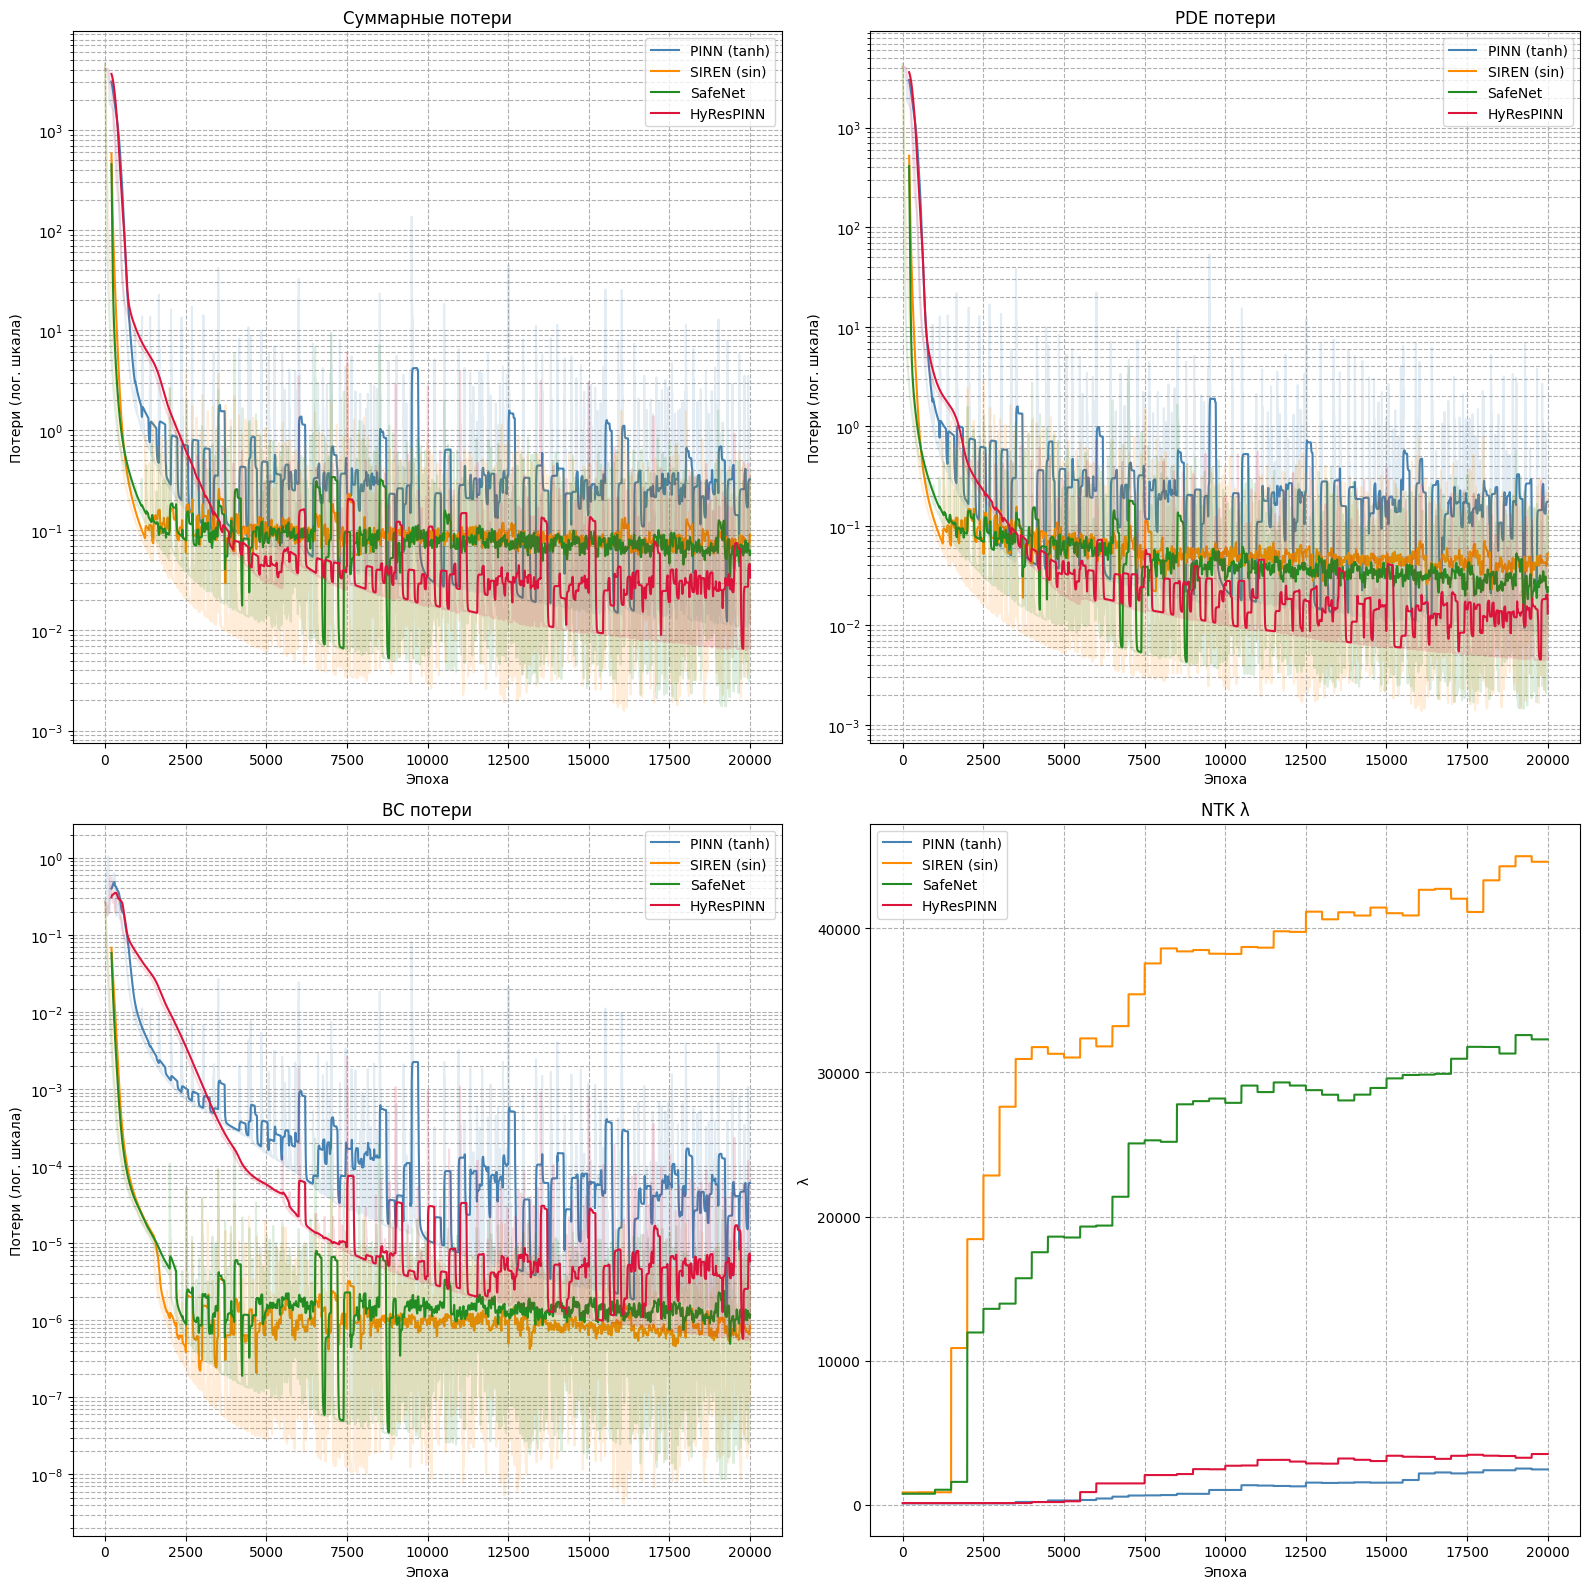

In [8]:
def moving_avg(x, w=200):
    return np.convolve(x, np.ones(w) / w, mode='valid')

epochs_full = np.arange(1, n_epochs + 1)
epochs_ma   = np.arange(w := 200, n_epochs + 1)

fig, axes = plt.subplots(2, 2, figsize=(16, 16))
axes = axes.flat
titles = ['Суммарные потери', 'PDE потери', 'BC потери']
keys   = ['total', 'pde', 'bc']
colors = {'pinn': 'steelblue', 'siren': 'darkorange', 'safe': 'forestgreen', 'hyres': 'crimson'}
hists  = {'pinn': history_pinn, 'siren': history_siren, 'safe': history_safe, 'hyres': history_hyres}
labels = {'pinn': 'PINN (tanh)', 'siren': 'SIREN (sin)', 'safe': 'SafeNet', 'hyres': 'HyResPINN'}

for ax, title, key in zip(axes[:3], titles, keys):
    for name, hist in hists.items():
        ax.semilogy(epochs_full, hist[key], color=colors[name], alpha=0.15)
        ax.semilogy(epochs_ma, moving_avg(hist[key]), color=colors[name], label=labels[name])
    ax.set_title(title)
    ax.set_xlabel('Эпоха')
    ax.set_ylabel('Потери (лог. шкала)')
    ax.legend()
    ax.grid(True, which='both', ls='--')

for name, hist in hists.items():
    axes[3].plot(epochs_full, hist['lambda'], color=colors[name], label=labels[name])
axes[3].set_title('NTK λ')
axes[3].set_xlabel('Эпоха')
axes[3].set_ylabel('λ')
axes[3].legend()
axes[3].grid(True, which='both', ls='--')

plt.tight_layout()
plt.savefig('models_learning.png', dpi=300, bbox_inches='tight')
plt.show()

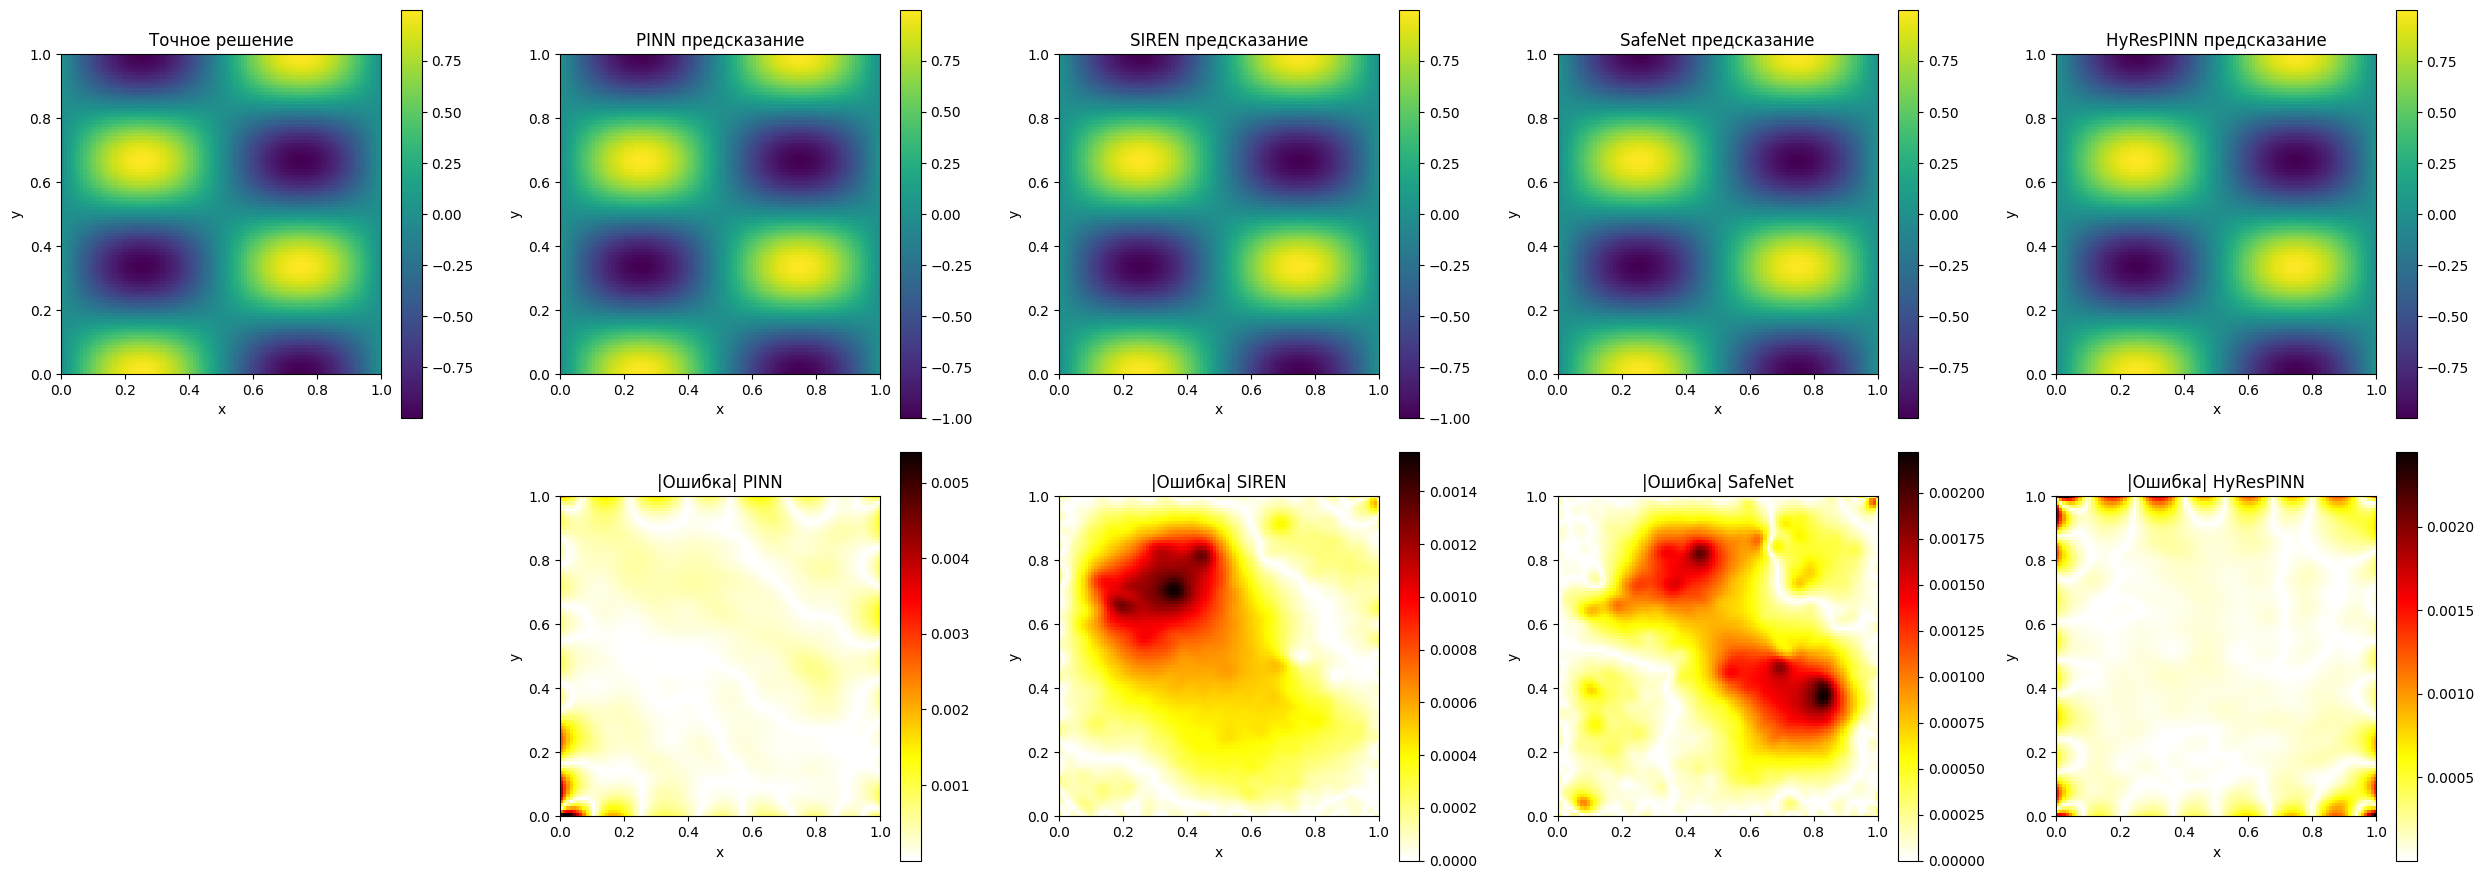

In [9]:
for model, save_path in [
    (model_pinn, save_path_pinn),
    (model_siren, save_path_siren), 
    (model_safe, save_path_safenet),
    (model_hyres, save_path_hyres),
    ]:
    model.load_state_dict(torch.load(save_path, map_location=device))
    model.eval()

N_vis = 100
x_lin = torch.linspace(0, 1, N_vis)
y_lin = torch.linspace(0, 1, N_vis)
XX, YY = torch.meshgrid(x_lin, y_lin, indexing='ij')
xy_vis = torch.stack([XX.flatten(), YY.flatten()], dim=1).to(device)

with torch.no_grad():
    u_true        = u_exact(xy_vis[:, 0], xy_vis[:, 1]).reshape(N_vis, N_vis).cpu().numpy()
    u_pred_pinn   = model_pinn(xy_vis).squeeze().reshape(N_vis, N_vis).cpu().numpy()
    u_pred_siren  = model_siren(xy_vis).squeeze().reshape(N_vis, N_vis).cpu().numpy()
    u_pred_safe   = model_safe(xy_vis).squeeze().reshape(N_vis, N_vis).cpu().numpy()
    u_pred_hyres  = model_hyres(xy_vis).squeeze().reshape(N_vis, N_vis).cpu().numpy()

err_pinn  = np.abs(u_pred_pinn  - u_true)
err_siren = np.abs(u_pred_siren - u_true)
err_safe  = np.abs(u_pred_safe  - u_true)
err_hyres = np.abs(u_pred_hyres - u_true)

fig, axes = plt.subplots(2, 5, figsize=(25, 9))

row0 = [(u_true, 'Точное решение'), (u_pred_pinn, 'PINN предсказание'),
        (u_pred_siren, 'SIREN предсказание'), (u_pred_safe, 'SafeNet предсказание'),
        (u_pred_hyres, 'HyResPINN предсказание')]
row1 = [(None, None), (err_pinn, '|Ошибка| PINN'), (err_siren, '|Ошибка| SIREN'),
        (err_safe, '|Ошибка| SafeNet'), (err_hyres, '|Ошибка| HyResPINN')]

for col, (data, title) in enumerate(row0):
    im = axes[0, col].imshow(data.T, origin='lower', extent=[0,1,0,1], cmap='viridis', aspect='equal')
    axes[0, col].set_title(title)
    axes[0, col].set_xlabel('x'); axes[0, col].set_ylabel('y')
    plt.colorbar(im, ax=axes[0, col])

for col, (data, title) in enumerate(row1):
    if data is None:
        axes[1, col].axis('off')
        continue
    im = axes[1, col].imshow(data.T, origin='lower', extent=[0,1,0,1], cmap='hot_r', aspect='equal')
    axes[1, col].set_title(title)
    axes[1, col].set_xlabel('x'); axes[1, col].set_ylabel('y')
    plt.colorbar(im, ax=axes[1, col])

plt.tight_layout()
plt.savefig('models_residuals.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
def relative_l2(u_pred, u_true):
    return np.linalg.norm(u_pred - u_true) / np.linalg.norm(u_true)

results = {
    'PINN (tanh)':   relative_l2(u_pred_pinn,  u_true),
    'SIREN (sin)':   relative_l2(u_pred_siren, u_true),
    'SafeNet':       relative_l2(u_pred_safe,  u_true),
    'HyResPINN':     relative_l2(u_pred_hyres, u_true),
}
best_model = min(results, key=results.get)

df = pd.DataFrame({
    'Модель':                  list(results.keys()),
    'Относительная ошибка L2': [f'{v:.4e}' for v in results.values()],
    'Параметров':              [
        sum(p.numel() for p in model_pinn.parameters()),
        sum(p.numel() for p in model_siren.parameters()),
        sum(p.numel() for p in model_safe.parameters()),
        sum(p.numel() for p in model_hyres.parameters()),
    ],
    'Лучше':                   ['✓' if k == best_model else '' for k in results],
})
print(df.to_string(index=False))


     Модель Относительная ошибка L2  Параметров Лучше
PINN (tanh)              8.2614e-04       83073      
SIREN (sin)              9.2714e-04        8577      
    SafeNet              1.2674e-03       24833      
  HyResPINN              5.1032e-04        8706     ✓


In [11]:
import json

best_hyres   = {}
torch.manual_seed(42)

all_params = {}
for name, save_path in [
    ('pinn', save_path_params_pinn),
    ('siren', save_path_params_siren),
    ('safenet', save_path_params_safenet),
    ('hyres', save_path_params_hyres),
]:
    with open(save_path, 'r') as f:
        all_params[name] = json.load(f)

best_pinn    = all_params['pinn']
best_siren   = all_params['siren']
best_safenet = all_params['safenet']
best_hyres   = all_params['hyres']

# --- PINN ---
_pinn_cfg = {
    'lr':            best_pinn.get('lr',           1e-3),
    'hidden_width':  best_pinn.get('hidden_width',  64),
    'hidden_layers': best_pinn.get('hidden_layers',  4),
    'lambda_bc':     best_pinn.get('lambda_bc',     10.0),
}
model_pinn = PINN(hidden_layers=_pinn_cfg['hidden_layers'],
                  hidden_width=_pinn_cfg['hidden_width']).to(device)
optimizer_pinn = torch.optim.Adam(model_pinn.parameters(), lr=_pinn_cfg['lr'])
print(f"PINN конфиг: {_pinn_cfg}  | параметров: {sum(p.numel() for p in model_pinn.parameters())}")

# --- SIREN ---
_siren_cfg = {
    'lr':            best_siren.get('lr',           5e-5),
    'omega_0':       best_siren.get('omega_0',       10),
    'hidden_width':  best_siren.get('hidden_width',  64),
    'hidden_layers': best_siren.get('hidden_layers',  4),
    'lambda_bc':     best_siren.get('lambda_bc',    10.0),
}
model_siren = SIREN(hidden_layers=_siren_cfg['hidden_layers'],
                    hidden_width=_siren_cfg['hidden_width'],
                    omega_0=_siren_cfg['omega_0']).to(device)
optimizer_siren = torch.optim.Adam(model_siren.parameters(), lr=_siren_cfg['lr'])
print(f"SIREN конфиг:    # сглаживание λ (EMA), клип убран{_siren_cfg}  | параметров: {sum(p.numel() for p in model_siren.parameters())}")

# --- SafeNet ---
_safe_cfg = {   # сглаживание λ (EMA), клип убран
    'lr':            best_safenet.get('lr',           1e-3),
    'n_fourier':     best_safenet.get('n_fourier',    256),
    'sigma':         best_safenet.get('sigma',          5.0),
    'hidden_width':  best_safenet.get('hidden_width',  64),
    'hidden_layers': best_safenet.get('hidden_layers',  1),
    'lambda_bc':     best_safenet.get('lambda_bc',    10.0),
}
model_safe = SafeNet(n_fourier=_safe_cfg['n_fourier'], sigma=_safe_cfg['sigma'],
                     hidden_layers=_safe_cfg['hidden_layers'],
                     hidden_width=_safe_cfg['hidden_width']).to(device)
optimizer_safe = torch.optim.Adam(model_safe.parameters(), lr=_safe_cfg['lr'])
print(f"SafeNet конфиг: {_safe_cfg}  | параметров: {sum(p.numel() for p in model_safe.parameters())}")

# --- HyResPINN ---
_hyres_cfg = {
    'lr':            best_hyres.get('lr',           1e-3),
    'hidden_width':  best_hyres.get('hidden_width',  64),
    'hidden_layers': best_hyres.get('hidden_layers',  3),
    'n_rbf':         best_hyres.get('n_rbf',         64),
    'lambda_bc':     best_hyres.get('lambda_bc',     10.0),
}
model_hyres = HyResPINN(hidden_layers=_hyres_cfg['hidden_layers'],
                        hidden_width=_hyres_cfg['hidden_width'],
                        n_rbf=_hyres_cfg['n_rbf']).to(device)
optimizer_hyres = torch.optim.Adam(model_hyres.parameters(), lr=_hyres_cfg['lr'])
print(f"HyResPINN конфиг: {_hyres_cfg}  | параметров: {sum(p.numel() for p in model_hyres.parameters())}")

save_path_pinn = 'saved_models/pinn.pth'
save_path_siren = 'saved_models/siren.pth'
save_path_safenet = 'saved_models/safenet.pth'
save_path_hyres = 'saved_models/hyres.pth'

PINN конфиг: {'lr': 0.00022235768427125718, 'hidden_width': 128, 'hidden_layers': 6, 'lambda_bc': 97.98189454789653}  | параметров: 83073
SIREN конфиг:    # сглаживание λ (EMA), клип убран{'lr': 7.670035337759973e-05, 'omega_0': 25, 'hidden_width': 64, 'hidden_layers': 3, 'lambda_bc': 92.70158971323106}  | параметров: 8577
SafeNet конфиг: {'lr': 0.0003350324221271991, 'n_fourier': 128, 'sigma': 11.747895410708516, 'hidden_width': 64, 'hidden_layers': 3, 'lambda_bc': 30.639354892348646}  | параметров: 24833
HyResPINN конфиг: {'lr': 0.0004607255680130148, 'hidden_width': 64, 'hidden_layers': 3, 'n_rbf': 32, 'lambda_bc': 98.67520913037332}  | параметров: 8706


In [12]:
from pinn import laplacian, f_rhs

def col_resid(model, xy_col):
    lap = laplacian(model, xy_col, retain_graph=True)
    f = f_rhs(xy_col[:, 0], xy_col[:, 1])
    return torch.abs(lap - f)

def bc_resid(model, xy_bc):
    u_pred = model(xy_bc).squeeze(1)
    u_true = u_exact(xy_bc[:, 0], xy_bc[:, 1])
    return torch.abs(u_pred - u_true)

def r3_resample_col(model, xy_col):
    resid = col_resid(model, xy_col)
    mean_resid = resid.detach().mean()
    mask = resid >= mean_resid
    
    resample_xy_col = torch.rand(mask.sum(), 2, device=device, requires_grad=True)
    retain_xy_col = xy_col[~mask].detach()
    
    new_xy_col = torch.concat([retain_xy_col, resample_xy_col])
    new_xy_col.requires_grad_(True)
    
    return new_xy_col

def r3_resample_bc(model, xy_bc):
    with torch.no_grad():
        resid = bc_resid(model, xy_bc)
        mean_resid = resid.mean()
        mask = resid >= mean_resid
    
    resample_xy_bc = sample_boundary(mask.sum()).to(device)
    retain_xy_bc = xy_bc[~mask].detach()
    
    new_xy_bc = torch.concat([retain_xy_bc, resample_xy_bc])
    new_xy_bc.requires_grad_(True)
    
    return new_xy_bc

In [15]:
NTK_UPDATE = 500
N_col      = 2000
N_bc       = 500
n_epochs   = 20000
log_every  = 1000
NTK_EMA    = 0.95

R3_tick = 1000

def compute_ntk_lambda(model, xy_col, xy_bc):
    """Возвращает λ = ||∇L_pde|| / ||∇L_bc||, без жёсткого клипа."""
    lp = pde_loss(model, xy_col)
    gp = torch.autograd.grad(lp, model.parameters(), allow_unused=True)
    norm_pde = sum(g.detach().norm()**2 for g in gp if g is not None).sqrt().item()
    lb = bc_loss(model, xy_bc)
    gb = torch.autograd.grad(lb, model.parameters(), allow_unused=True)
    norm_bc = sum(g.detach().norm()**2 for g in gb if g is not None).sqrt().item()
    return norm_pde / (norm_bc + 1e-8)

xy_col_train_pinn = torch.rand(N_col, 2, device=device, requires_grad=True)
xy_bc_train_pinn  = sample_boundary(N_bc).to(device)
xy_col_train_siren = torch.rand(N_col, 2, device=device, requires_grad=True)
xy_bc_train_siren  = sample_boundary(N_bc).to(device)
xy_col_train_safenet = torch.rand(N_col, 2, device=device, requires_grad=True)
xy_bc_train_safenet  = sample_boundary(N_bc).to(device)
xy_col_train_hyres = torch.rand(N_col, 2, device=device, requires_grad=True)
xy_bc_train_hyres  = sample_boundary(N_bc).to(device)

lam_p = float(_pinn_cfg['lambda_bc'])
lam_s = float(_siren_cfg['lambda_bc'])
lam_f = float(_safe_cfg['lambda_bc'])
lam_h = float(_hyres_cfg['lambda_bc'])

history_pinn  = {'pde': [], 'bc': [], 'total': [], 'lambda': [], 'resid_mean': [], 'retain_count': [], 'collocation_points': []}
history_siren = {'pde': [], 'bc': [], 'total': [], 'lambda': [], 'resid_mean': [], 'retain_count': [], 'collocation_points': []}
history_safe  = {'pde': [], 'bc': [], 'total': [], 'lambda': [], 'resid_mean': [], 'retain_count': [], 'collocation_points': []}
history_hyres = {'pde': [], 'bc': [], 'total': [], 'lambda': [], 'resid_mean': [], 'retain_count': [], 'collocation_points': []}

for epoch in range(1, n_epochs + 1):
    if epoch % NTK_UPDATE == 1:
        # EMA обновление: λ_new = α·λ_old + (1-α)·λ_ntk
        lam_p = NTK_EMA * lam_p + (1 - NTK_EMA) * compute_ntk_lambda(model_pinn,  xy_col_train_pinn, xy_bc_train_pinn)
        lam_s = NTK_EMA * lam_s + (1 - NTK_EMA) * compute_ntk_lambda(model_siren, xy_col_train_siren, xy_bc_train_siren)
        lam_f = NTK_EMA * lam_f + (1 - NTK_EMA) * compute_ntk_lambda(model_safe,  xy_col_train_safenet, xy_bc_train_safenet)
        lam_h = NTK_EMA * lam_h + (1 - NTK_EMA) * compute_ntk_lambda(model_hyres, xy_col_train_hyres, xy_bc_train_hyres)

    for xy_col_train in [xy_col_train_pinn, xy_col_train_siren, xy_col_train_safenet, xy_col_train_hyres]:
        xy_col_train.grad = None

    for model, opt, lam, hist, save_path, xy_col_train, xy_bc_train in [
        (model_pinn,  optimizer_pinn,  lam_p, history_pinn, save_path_pinn, xy_col_train_pinn, xy_bc_train_pinn),
        (model_siren, optimizer_siren, lam_s, history_siren, save_path_siren, xy_col_train_siren, xy_bc_train_siren),
        (model_safe,  optimizer_safe,  lam_f, history_safe, save_path_safenet, xy_col_train_safenet, xy_bc_train_safenet),
        (model_hyres, optimizer_hyres, lam_h, history_hyres, save_path_hyres, xy_col_train_hyres, xy_bc_train_hyres),
    ]:
        opt.zero_grad()
        lp = pde_loss(model, xy_col_train)
        lb = bc_loss(model, xy_bc_train)
        loss = lp + lam * lb
        loss.backward()
        opt.step()

        if epoch != 1 and min(hist['total']) > loss.item():
            torch.save(model.state_dict(), 'r3_' + save_path)
        hist['pde'].append(lp.item())
        hist['bc'].append(lb.item())
        hist['total'].append(loss.item())
        hist['lambda'].append(lam)
        
        resid = col_resid(model, xy_col_train)
        mean_resid = resid.detach().mean()
        hist['resid_mean'].append(mean_resid.cpu())

        if epoch % R3_tick == 1:
            mask = resid >= mean_resid
            hist['retain_count'] += [mask.sum().cpu()] * R3_tick
            hist['collocation_points'] += xy_col_train.cpu().tolist()
        
    # R3
    if epoch % R3_tick == 0:
        xy_col_train_pinn = r3_resample_col(model_pinn, xy_col_train_pinn)
        xy_bc_train_pinn = r3_resample_bc(model_pinn, xy_bc_train_pinn)
        xy_col_train_siren = r3_resample_col(model_siren, xy_col_train_siren)
        xy_bc_train_siren = r3_resample_bc(model_siren, xy_bc_train_siren)
        xy_col_train_safenet = r3_resample_col(model_safe, xy_col_train_safenet)
        xy_bc_train_safenet = r3_resample_bc(model_safe, xy_bc_train_safenet)
        xy_col_train_hyres = r3_resample_col(model_hyres, xy_col_train_hyres)
        xy_bc_train_hyres = r3_resample_bc(model_hyres, xy_bc_train_hyres)

    if epoch % log_every == 0:
        print(f'Эпоха {epoch:5d} | '
              f'PINN: {min(history_pinn["total"]):.3e} | '
              f'SIREN: {min(history_siren["total"]):.3e} | '
              f'Safe: {min(history_safe["total"]):.3e} | '
              f'HyRes: {min(history_hyres["total"]):.3e}')

print('Обучение завершено')


Эпоха  1000 | PINN: 1.514e+00 | SIREN: 1.025e-01 | Safe: 1.685e-01 | HyRes: 8.622e+00
Эпоха  2000 | PINN: 3.011e-01 | SIREN: 2.437e-02 | Safe: 4.319e-02 | HyRes: 8.990e-01
Эпоха  3000 | PINN: 1.025e-01 | SIREN: 1.083e-02 | Safe: 2.353e-02 | HyRes: 2.242e-01
Эпоха  4000 | PINN: 5.513e-02 | SIREN: 7.403e-03 | Safe: 1.604e-02 | HyRes: 5.964e-02
Эпоха  5000 | PINN: 2.803e-02 | SIREN: 5.371e-03 | Safe: 1.441e-02 | HyRes: 2.854e-02
Эпоха  6000 | PINN: 2.803e-02 | SIREN: 5.371e-03 | Safe: 1.031e-02 | HyRes: 1.852e-02
Эпоха  7000 | PINN: 2.267e-02 | SIREN: 3.783e-03 | Safe: 8.659e-03 | HyRes: 1.199e-02
Эпоха  8000 | PINN: 1.759e-02 | SIREN: 3.783e-03 | Safe: 8.355e-03 | HyRes: 1.199e-02
Эпоха  9000 | PINN: 1.759e-02 | SIREN: 3.262e-03 | Safe: 6.010e-03 | HyRes: 1.040e-02
Эпоха 10000 | PINN: 1.759e-02 | SIREN: 2.697e-03 | Safe: 5.701e-03 | HyRes: 7.704e-03
Эпоха 11000 | PINN: 1.440e-02 | SIREN: 2.697e-03 | Safe: 4.698e-03 | HyRes: 6.401e-03
Эпоха 12000 | PINN: 1.068e-02 | SIREN: 2.697e-03 | Saf

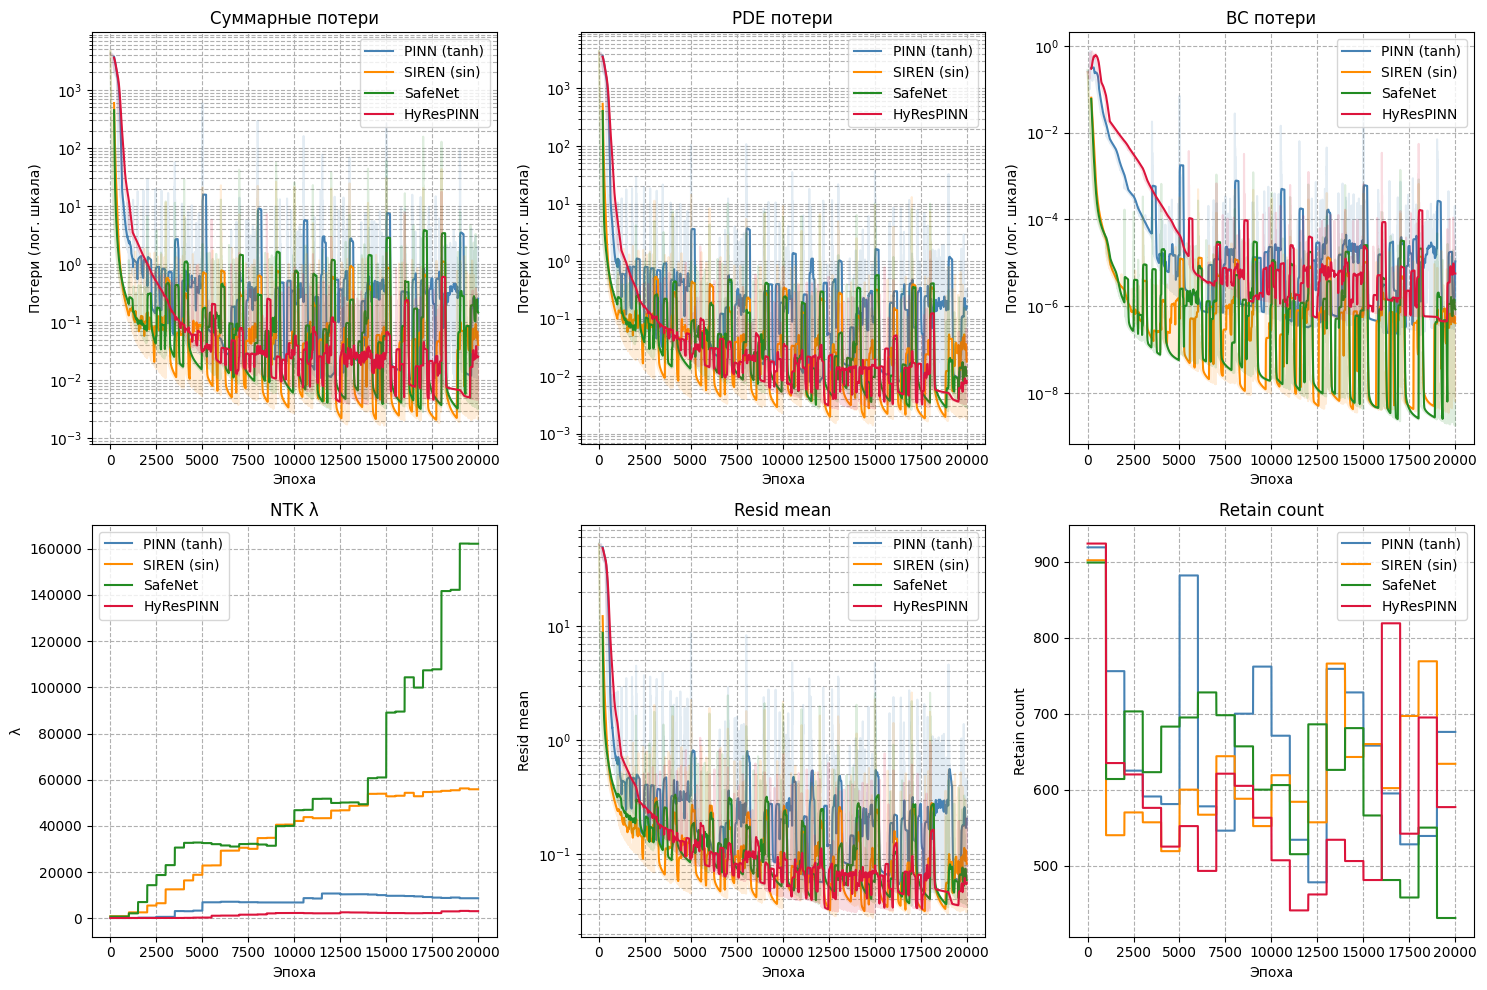

In [16]:
def moving_avg(x, w=200):
    return np.convolve(x, np.ones(w) / w, mode='valid')

epochs_full = np.arange(1, n_epochs + 1)
epochs_ma   = np.arange(w := 200, n_epochs + 1)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flat
titles = ['Суммарные потери', 'PDE потери', 'BC потери']
keys   = ['total', 'pde', 'bc']
colors = {'pinn': 'steelblue', 'siren': 'darkorange', 'safe': 'forestgreen', 'hyres': 'crimson'}
hists  = {'pinn': history_pinn, 'siren': history_siren, 'safe': history_safe, 'hyres': history_hyres}
labels = {'pinn': 'PINN (tanh)', 'siren': 'SIREN (sin)', 'safe': 'SafeNet', 'hyres': 'HyResPINN'}

for ax, title, key in zip(axes[:3], titles, keys):
    for name, hist in hists.items():
        ax.semilogy(epochs_full, hist[key], color=colors[name], alpha=0.15)
        ax.semilogy(epochs_ma, moving_avg(hist[key]), color=colors[name], label=labels[name])
    ax.set_title(title)
    ax.set_xlabel('Эпоха')
    ax.set_ylabel('Потери (лог. шкала)')
    ax.legend()
    ax.grid(True, which='both', ls='--')

for name, hist in hists.items():
    axes[3].plot(epochs_full, hist['lambda'], color=colors[name], label=labels[name])
    axes[4].plot(epochs_full, hist['resid_mean'], color=colors[name], alpha=0.15)
    axes[4].plot(epochs_ma, moving_avg(hist['resid_mean']), color=colors[name], label=labels[name])
    axes[5].plot(epochs_full, hist['retain_count'], color=colors[name], label=labels[name])

axes[3].set_title('NTK λ')
axes[3].set_xlabel('Эпоха')
axes[3].set_ylabel('λ')
axes[3].legend()
axes[3].grid(True, which='both', ls='--')

axes[4].set_yscale('log')
axes[4].set_title('Resid mean')
axes[4].set_xlabel('Эпоха')
axes[4].set_ylabel('Resid mean')
axes[4].legend()
axes[4].grid(True, which='both', ls='--')

axes[5].set_title('Retain count')
axes[5].set_xlabel('Эпоха')
axes[5].set_ylabel('Retain count')
axes[5].legend()
axes[5].grid(True, which='both', ls='--')

plt.tight_layout()
plt.savefig('r3_models_learning.png', dpi=300, bbox_inches='tight')
plt.show()

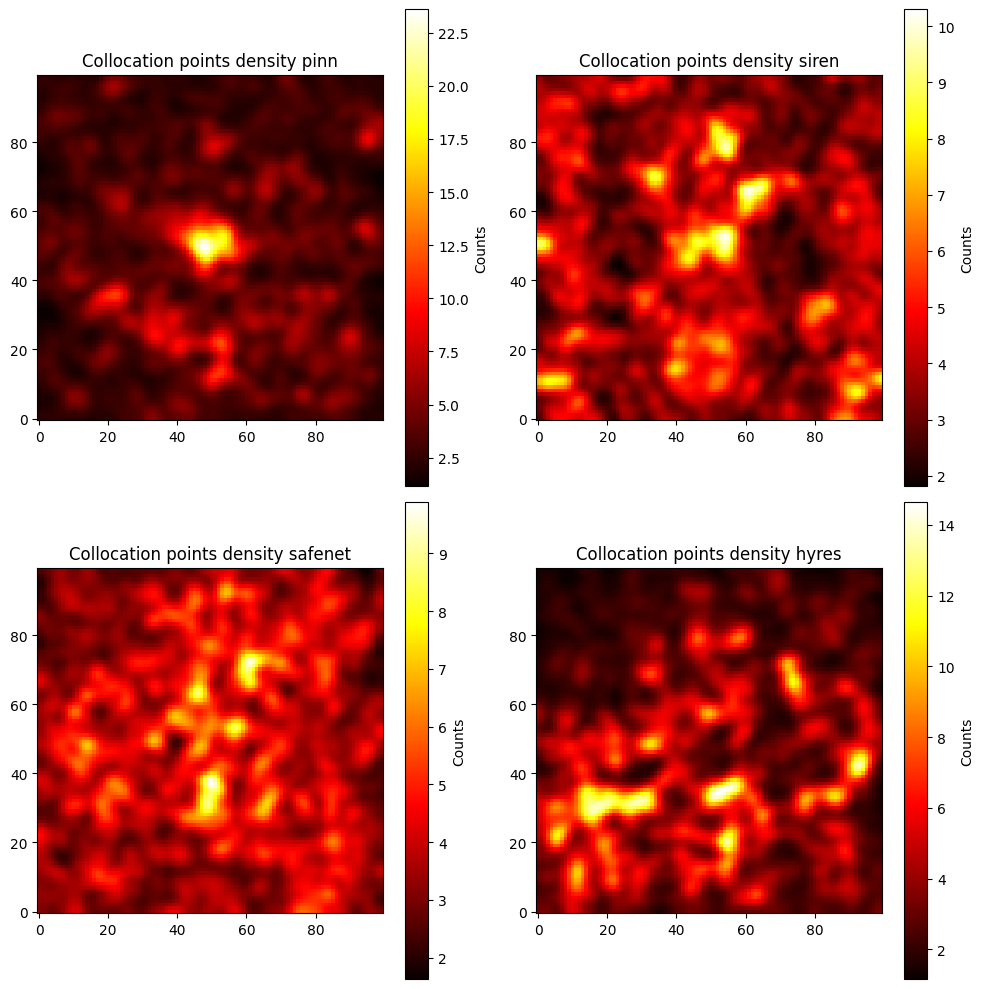

In [17]:
from scipy.ndimage import gaussian_filter

fig, axs = plt.subplots(2, 2, figsize=(10, 10))
ax1, ax2, ax3, ax4 = axs.flat

for hist, name, ax in [
    (history_pinn, 'pinn', ax1),
    (history_siren, 'siren', ax2),
    (history_safe, 'safenet', ax3),
    (history_hyres, 'hyres', ax4),
]:
    x = np.array(hist['collocation_points'])[:, 0]
    y = np.array(hist['collocation_points'])[:, 1]

    H, _, _ = np.histogram2d(x, y, bins=100)
    sigma = 2.0
    H_smooth = gaussian_filter(H, sigma=sigma)

    im = ax.imshow(H_smooth.T, origin='lower', cmap='hot')
    ax.set_title(f'Collocation points density {name}')
    plt.colorbar(im, label='Counts')
plt.tight_layout()
plt.savefig('r3_models_collocation_density.png', dpi=300, bbox_inches='tight')
plt.show()

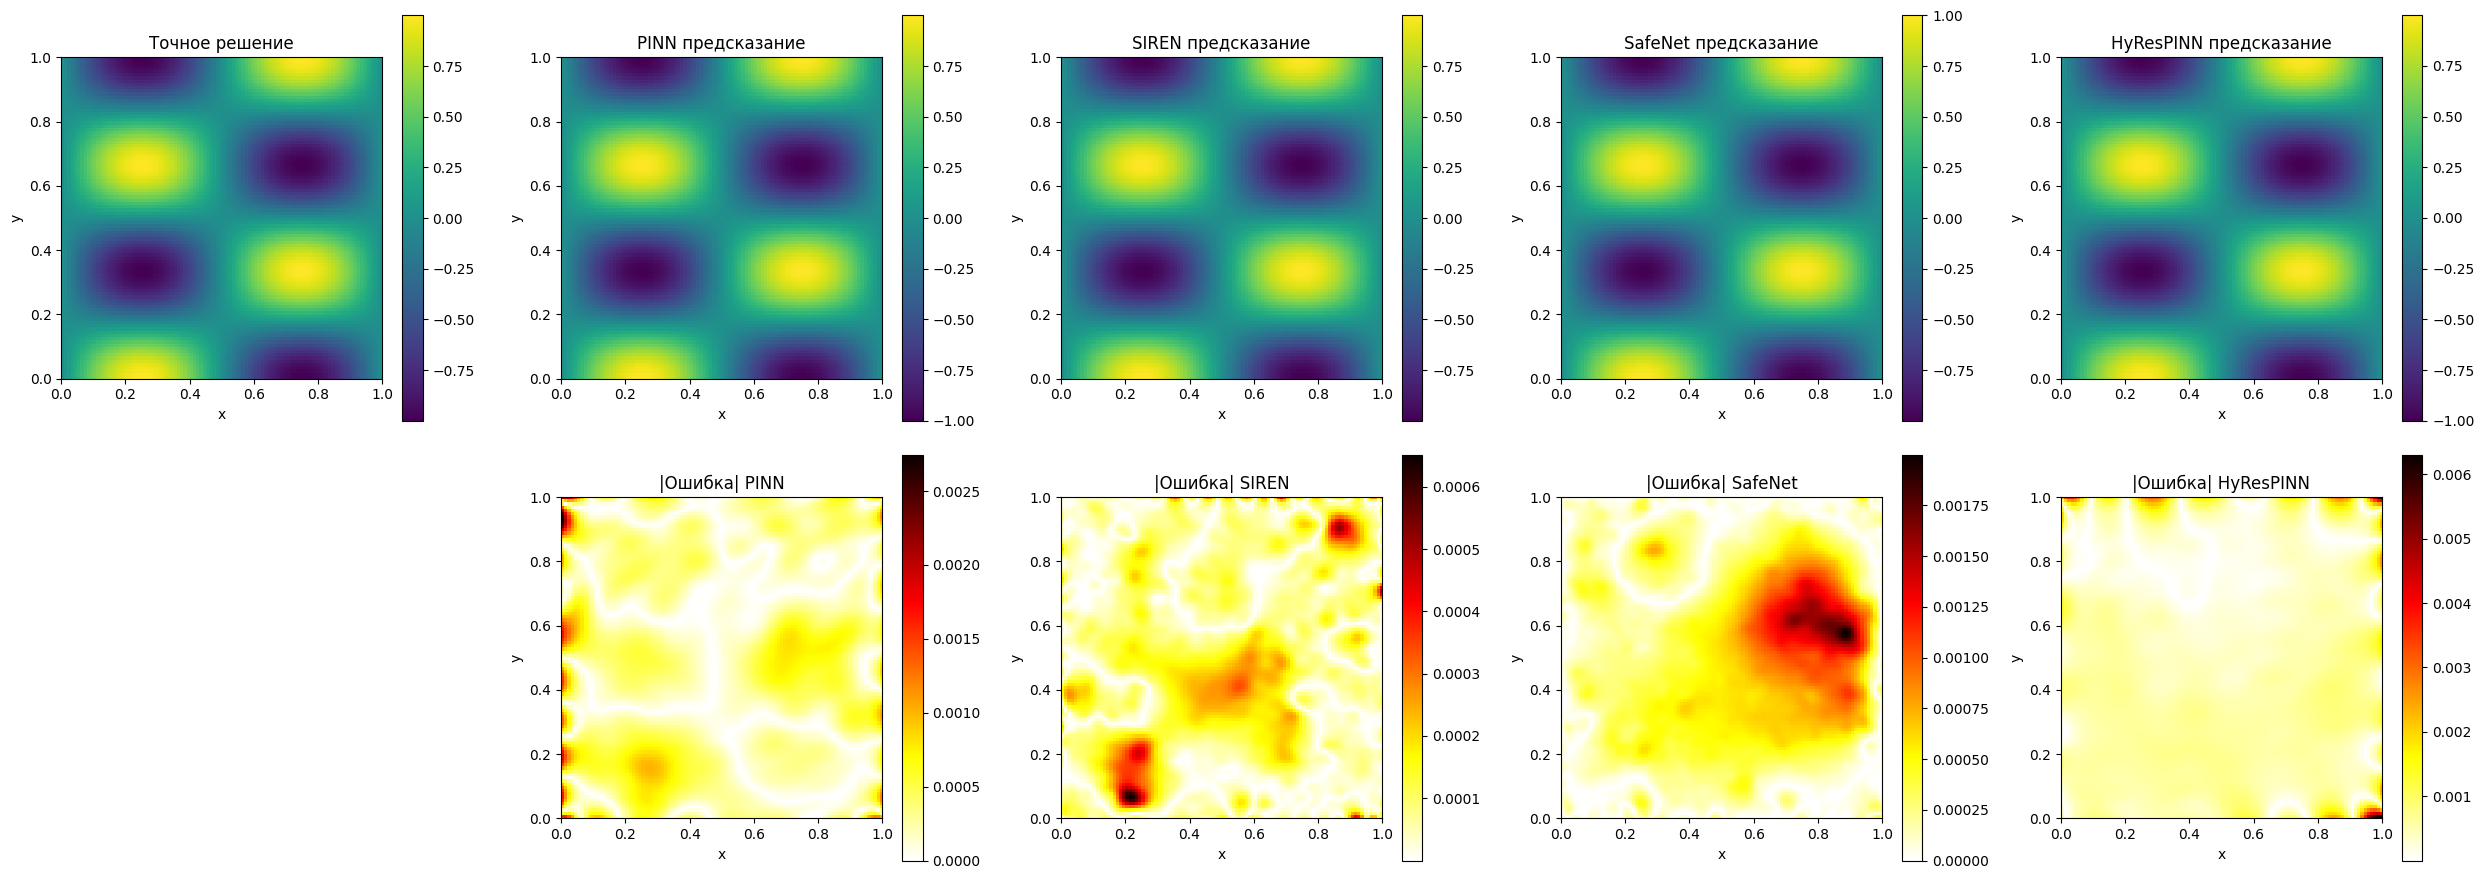

In [18]:
for model, save_path in [
    (model_pinn, 'r3_' + save_path_pinn),
    (model_siren, 'r3_' + save_path_siren), 
    (model_safe, 'r3_' + save_path_safenet),
    (model_hyres, 'r3_' + save_path_hyres),
    ]:
    model.load_state_dict(torch.load(save_path, map_location=device))
    model.eval()

N_vis = 100
x_lin = torch.linspace(0, 1, N_vis)
y_lin = torch.linspace(0, 1, N_vis)
XX, YY = torch.meshgrid(x_lin, y_lin, indexing='ij')
xy_vis = torch.stack([XX.flatten(), YY.flatten()], dim=1).to(device)

with torch.no_grad():
    u_true        = u_exact(xy_vis[:, 0], xy_vis[:, 1]).reshape(N_vis, N_vis).cpu().numpy()
    u_pred_pinn   = model_pinn(xy_vis).squeeze().reshape(N_vis, N_vis).cpu().numpy()
    u_pred_siren  = model_siren(xy_vis).squeeze().reshape(N_vis, N_vis).cpu().numpy()
    u_pred_safe   = model_safe(xy_vis).squeeze().reshape(N_vis, N_vis).cpu().numpy()
    u_pred_hyres  = model_hyres(xy_vis).squeeze().reshape(N_vis, N_vis).cpu().numpy()

err_pinn  = np.abs(u_pred_pinn  - u_true)
err_siren = np.abs(u_pred_siren - u_true)
err_safe  = np.abs(u_pred_safe  - u_true)
err_hyres = np.abs(u_pred_hyres - u_true)

fig, axes = plt.subplots(2, 5, figsize=(25, 9))

row0 = [(u_true, 'Точное решение'), (u_pred_pinn, 'PINN предсказание'),
        (u_pred_siren, 'SIREN предсказание'), (u_pred_safe, 'SafeNet предсказание'),
        (u_pred_hyres, 'HyResPINN предсказание')]
row1 = [(None, None), (err_pinn, '|Ошибка| PINN'), (err_siren, '|Ошибка| SIREN'),
        (err_safe, '|Ошибка| SafeNet'), (err_hyres, '|Ошибка| HyResPINN')]

for col, (data, title) in enumerate(row0):
    im = axes[0, col].imshow(data.T, origin='lower', extent=[0,1,0,1], cmap='viridis', aspect='equal')
    axes[0, col].set_title(title)
    axes[0, col].set_xlabel('x'); axes[0, col].set_ylabel('y')
    plt.colorbar(im, ax=axes[0, col])

for col, (data, title) in enumerate(row1):
    if data is None:
        axes[1, col].axis('off')
        continue
    im = axes[1, col].imshow(data.T, origin='lower', extent=[0,1,0,1], cmap='hot_r', aspect='equal')
    axes[1, col].set_title(title)
    axes[1, col].set_xlabel('x'); axes[1, col].set_ylabel('y')
    plt.colorbar(im, ax=axes[1, col])

plt.tight_layout()
plt.savefig('r3_models_residuals.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
def relative_l2(u_pred, u_true):
    return np.linalg.norm(u_pred - u_true) / np.linalg.norm(u_true)

results = {
    'PINN (tanh)':   relative_l2(u_pred_pinn,  u_true),
    'SIREN (sin)':   relative_l2(u_pred_siren, u_true),
    'SafeNet':       relative_l2(u_pred_safe,  u_true),
    'HyResPINN':     relative_l2(u_pred_hyres, u_true),
}
best_model = min(results, key=results.get)

df = pd.DataFrame({
    'Модель':                  list(results.keys()),
    'Относительная ошибка L2': [f'{v:.4e}' for v in results.values()],
    'Параметров':              [
        sum(p.numel() for p in model_pinn.parameters()),
        sum(p.numel() for p in model_siren.parameters()),
        sum(p.numel() for p in model_safe.parameters()),
        sum(p.numel() for p in model_hyres.parameters()),
    ],
    'Лучше':                   ['✓' if k == best_model else '' for k in results],
})
print(df.to_string(index=False))


     Модель Относительная ошибка L2  Параметров Лучше
PINN (tanh)              7.9471e-04       83073      
SIREN (sin)              2.5021e-04        8577     ✓
    SafeNet              1.0686e-03       24833      
  HyResPINN              1.2715e-03        8706      
